# Task 1 – Audio Preprocessing and Visualization

## Objective
Load an audio sample, apply preprocessing techniques, and compare the original and processed audio using multiple visualizations:
- Waveform
- Mel Spectrogram
- MFCC Heatmap
- FFT Spectrum

Dataset Used:
- LibriSpeech (sample audio)

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
audio_path = librosa.ex("libri1")

audio, sr = librosa.load(audio_path, sr=None)

print("Sample Rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

Sample Rate: 22050
Duration: 14.84 seconds


## Audio Preprocessing

The following preprocessing steps are performed:

- Resampling to 16 kHz
- Amplitude Normalization
- Silence Trimming

In [3]:
# Resample
audio_resampled = librosa.resample(audio, orig_sr=sr, target_sr=16000)

# Normalize
audio_normalized = librosa.util.normalize(audio_resampled)

# Trim silence
audio_processed, _ = librosa.effects.trim(audio_normalized)

new_sr = 16000

print("Processed Duration:", len(audio_processed)/new_sr, "seconds")

Processed Duration: 14.808 seconds


## Waveform Comparison

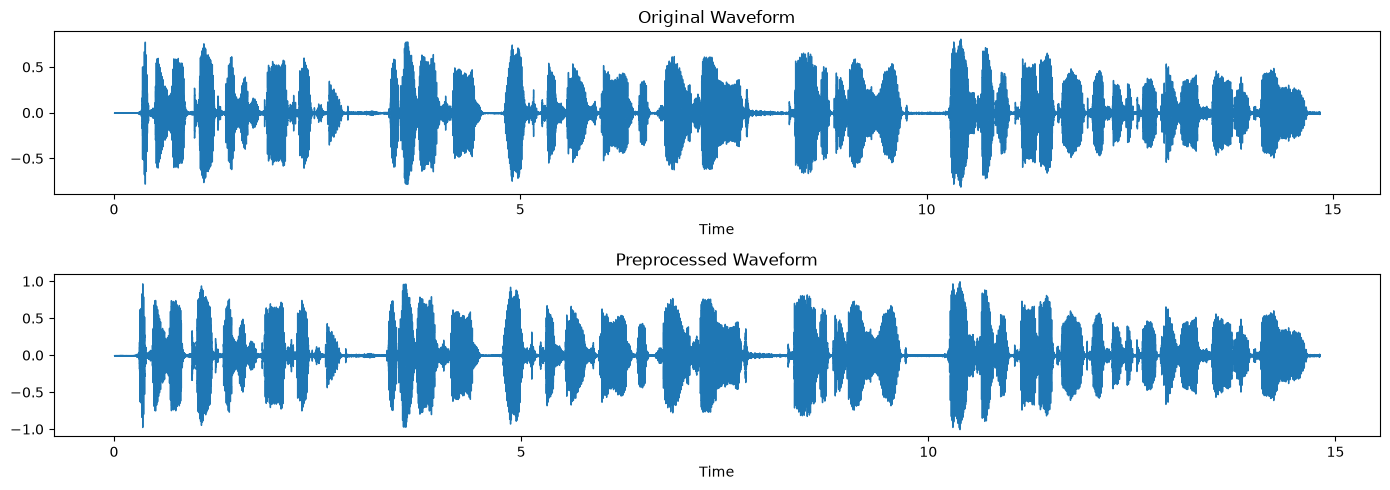

In [4]:
plt.figure(figsize=(14,5))

plt.subplot(2,1,1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Original Waveform")

plt.subplot(2,1,2)
librosa.display.waveshow(audio_processed, sr=new_sr)
plt.title("Preprocessed Waveform")

plt.tight_layout()
plt.show()

## Mel Spectrogram Comparison

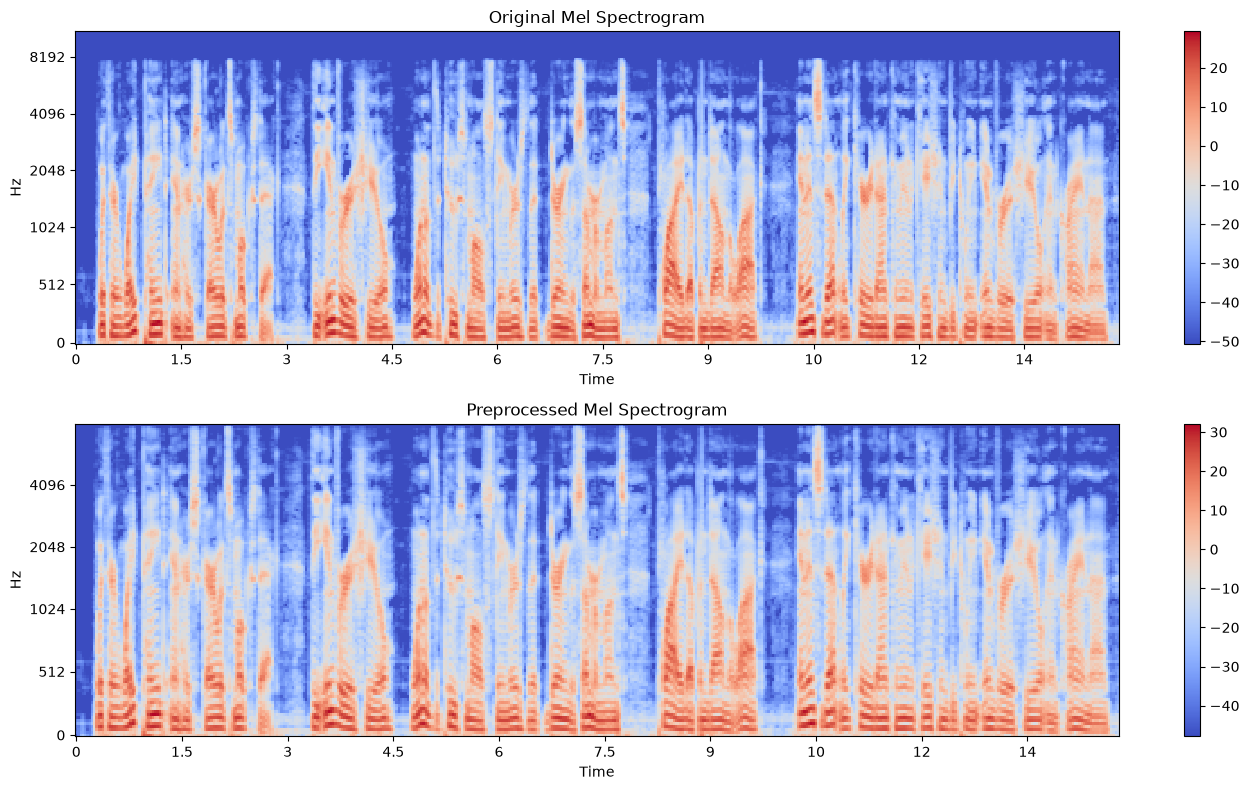

In [5]:
mel_original = librosa.feature.melspectrogram(y=audio, sr=sr)
mel_processed = librosa.feature.melspectrogram(y=audio_processed, sr=new_sr)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
librosa.display.specshow(
    librosa.power_to_db(mel_original),
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.title("Original Mel Spectrogram")
plt.colorbar()

plt.subplot(2,1,2)
librosa.display.specshow(
    librosa.power_to_db(mel_processed),
    sr=new_sr,
    x_axis='time',
    y_axis='mel'
)
plt.title("Preprocessed Mel Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

## MFCC Heatmap Comparison

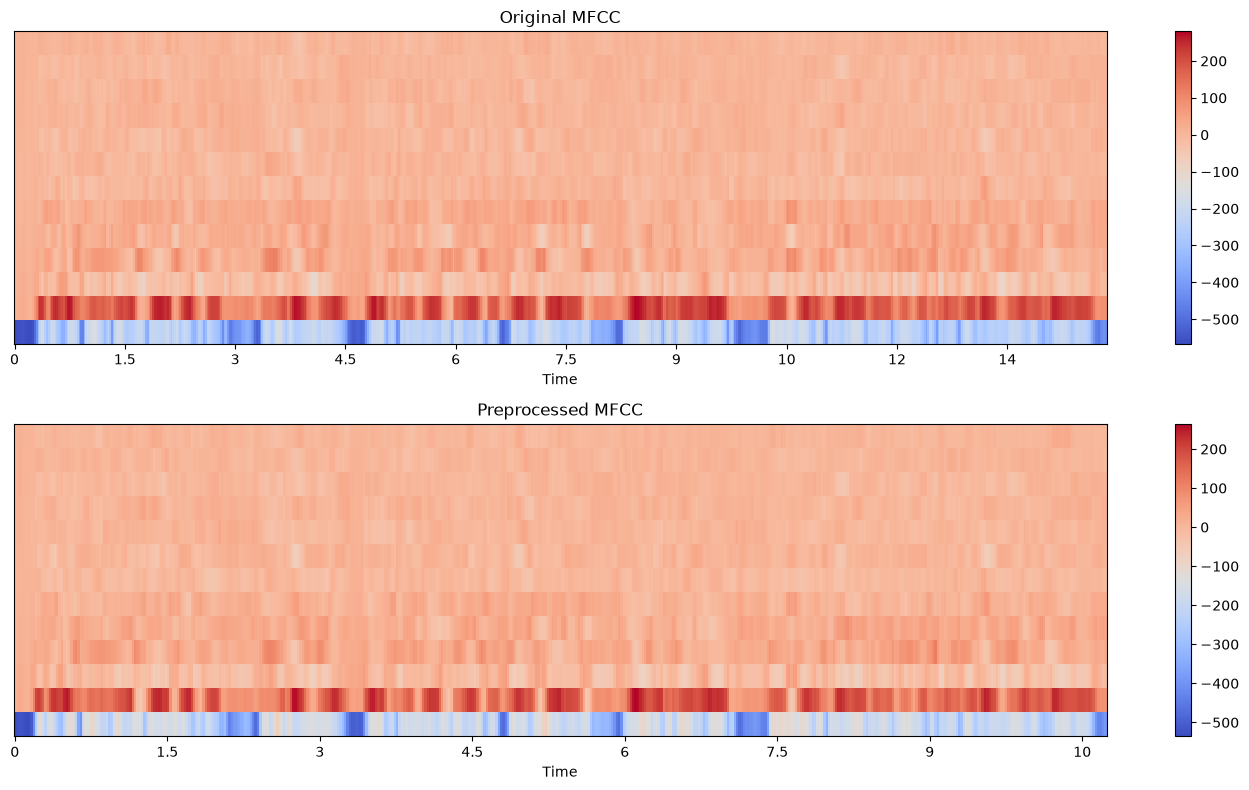

In [6]:
mfcc_original = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
mfcc_processed = librosa.feature.mfcc(y=audio_processed, sr=new_sr, n_mfcc=13)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
librosa.display.specshow(mfcc_original, x_axis='time')
plt.title("Original MFCC")
plt.colorbar()

plt.subplot(2,1,2)
librosa.display.specshow(mfcc_processed, x_axis='time')
plt.title("Preprocessed MFCC")
plt.colorbar()

plt.tight_layout()
plt.show()

## FFT Spectrum Comparison

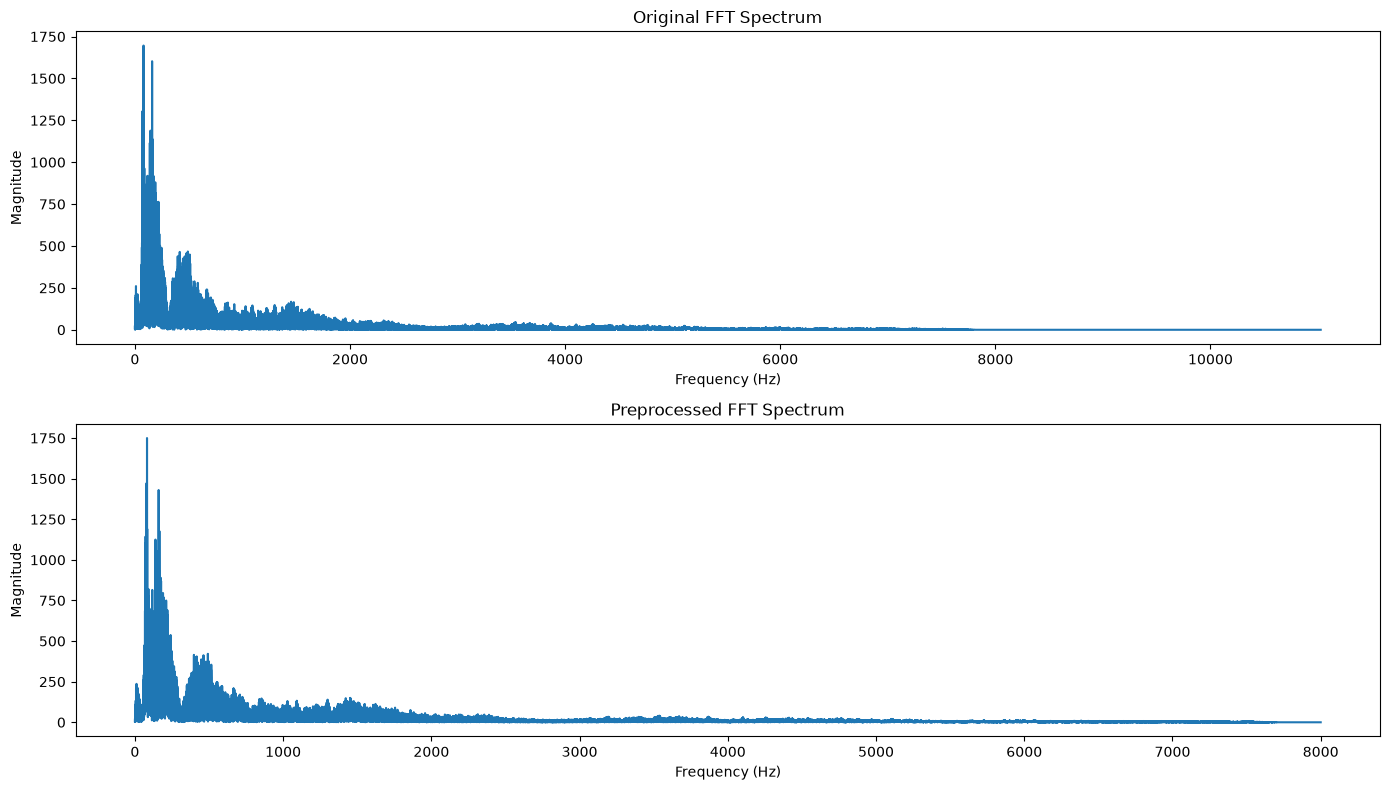

In [7]:
fft_original = np.abs(np.fft.rfft(audio))
freq_original = np.fft.rfftfreq(len(audio), 1/sr)

fft_processed = np.abs(np.fft.rfft(audio_processed))
freq_processed = np.fft.rfftfreq(len(audio_processed), 1/new_sr)

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
plt.plot(freq_original, fft_original)
plt.title("Original FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.subplot(2,1,2)
plt.plot(freq_processed, fft_processed)
plt.title("Preprocessed FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

# Speech Denoising using Pretrained DTLN Model

Load the pretrained DTLN TFLite models and initialize the interpreters for speech denoising.

In [11]:
import os
import soundfile as sf
import tensorflow as tf
import numpy as np

MODEL1 = "DTLN-master/DTLN-master/pretrained_model/model_1.tflite"
MODEL2 = "DTLN-master/DTLN-master/pretrained_model/model_2.tflite"

OUTPUT_DIR = "denoised_audio"
os.makedirs(OUTPUT_DIR, exist_ok=True)

interpreter_1 = tf.lite.Interpreter(model_path=MODEL1)
interpreter_1.allocate_tensors()

interpreter_2 = tf.lite.Interpreter(model_path=MODEL2)
interpreter_2.allocate_tensors()

input_details_1 = interpreter_1.get_input_details()
output_details_1 = interpreter_1.get_output_details()

input_details_2 = interpreter_2.get_input_details()
output_details_2 = interpreter_2.get_output_details()

print("DTLN model loaded successfully.")

DTLN model loaded successfully.


# Denoise a Speech Recording

The following function processes a noisy speech recording using the pretrained DTLN model and saves the denoised output.


In [12]:
block_len = 512
block_shift = 128

states_1 = np.zeros(input_details_1[1]["shape"], dtype=np.float32)
states_2 = np.zeros(input_details_2[1]["shape"], dtype=np.float32)

def denoise_audio(audio_path, output_path):
    audio, sr = sf.read(audio_path)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != 16000:
        raise ValueError("DTLN expects 16 kHz audio.")

    in_buffer = np.zeros(block_len, dtype=np.float32)
    out_buffer = np.zeros(block_len, dtype=np.float32)

    output = []

    global states_1, states_2
    states_1.fill(0)
    states_2.fill(0)

    for idx in range(0, len(audio), block_shift):

        chunk = audio[idx:idx+block_shift]

        if len(chunk) < block_shift:
            chunk = np.pad(chunk, (0, block_shift-len(chunk)))

        in_buffer[:-block_shift] = in_buffer[block_shift:]
        in_buffer[-block_shift:] = chunk

        fft = np.fft.rfft(in_buffer)
        mag = np.abs(fft)
        phase = np.angle(fft)

        mag = mag.reshape(1,1,-1).astype(np.float32)

        interpreter_1.set_tensor(input_details_1[0]["index"], mag)
        interpreter_1.set_tensor(input_details_1[1]["index"], states_1)
        interpreter_1.invoke()

        mask = interpreter_1.get_tensor(output_details_1[0]["index"])
        states_1 = interpreter_1.get_tensor(output_details_1[1]["index"])

        estimated = mag * mask * np.exp(1j * phase)
        estimated = np.fft.irfft(estimated)

        estimated = estimated.reshape(1,1,-1).astype(np.float32)

        interpreter_2.set_tensor(input_details_2[0]["index"], estimated)
        interpreter_2.set_tensor(input_details_2[1]["index"], states_2)
        interpreter_2.invoke()

        out_block = interpreter_2.get_tensor(output_details_2[0]["index"])
        states_2 = interpreter_2.get_tensor(output_details_2[1]["index"])

        out_buffer[:-block_shift] = out_buffer[block_shift:]
        out_buffer[-block_shift:] = 0
        out_buffer += out_block.squeeze()

        output.extend(out_buffer[:block_shift])

    sf.write(output_path, np.array(output), sr)

# Run Denoising

Run the pretrained DTLN model on the selected noisy speech sample and save the denoised output.

In [14]:
noisy_file = os.path.join("noisy_audio", os.listdir("noisy_audio")[0])

denoised_file = os.path.join(
    OUTPUT_DIR,
    "denoised.wav"
)

denoise_audio(noisy_file, denoised_file)

print("Denoised audio saved to:", denoised_file)

Denoised audio saved to: denoised_audio\denoised.wav


# Compare Noisy and Denoised Audio

Visualize the waveform and Mel spectrogram of the noisy and denoised speech signals.

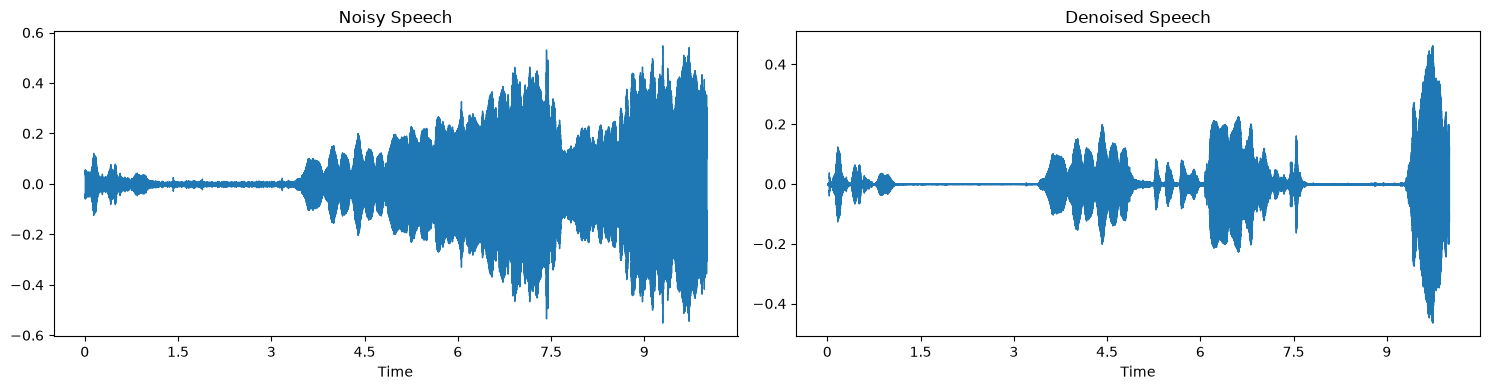

In [16]:
noisy, sr = librosa.load(noisy_file, sr=16000)
clean, sr = librosa.load(denoised_file, sr=16000)

plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
librosa.display.waveshow(noisy, sr=sr)
plt.title("Noisy Speech")

plt.subplot(1,2,2)
librosa.display.waveshow(clean, sr=sr)
plt.title("Denoised Speech")

plt.tight_layout()
plt.show()

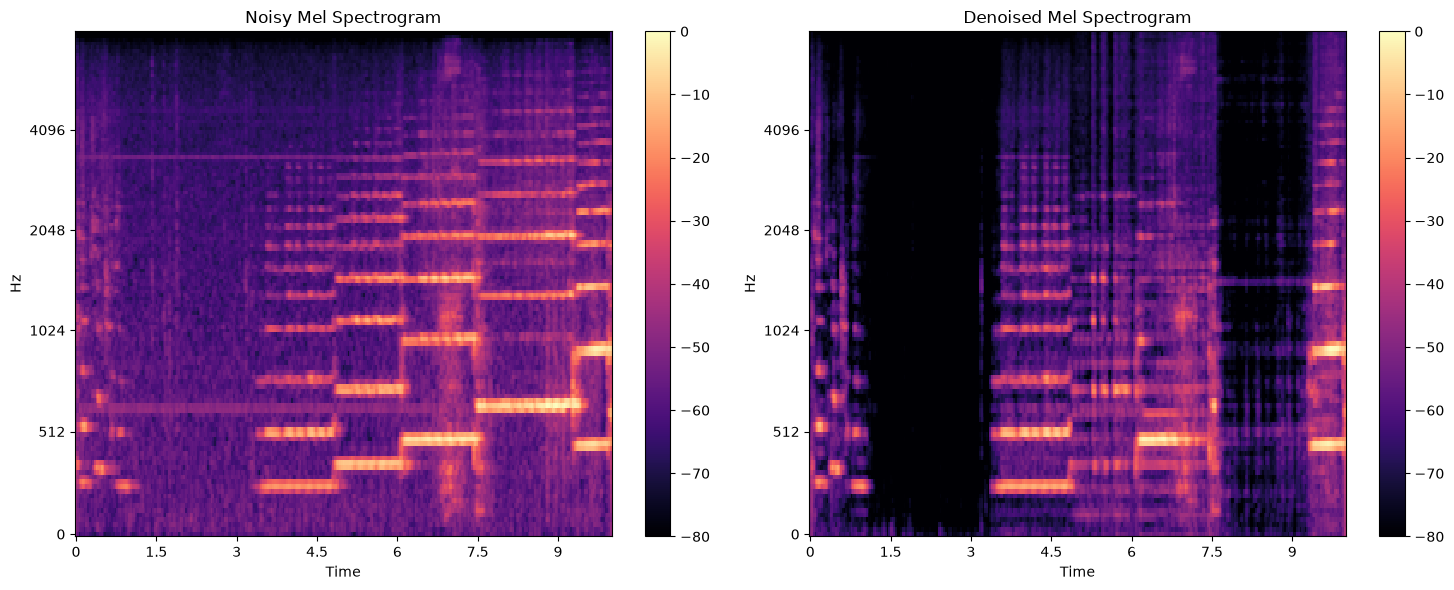

In [17]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
librosa.display.specshow(
    librosa.power_to_db(
        librosa.feature.melspectrogram(y=noisy, sr=sr),
        ref=np.max
    ),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.title("Noisy Mel Spectrogram")
plt.colorbar()

plt.subplot(1,2,2)
librosa.display.specshow(
    librosa.power_to_db(
        librosa.feature.melspectrogram(y=clean, sr=sr),
        ref=np.max
    ),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.title("Denoised Mel Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()